<a href="https://colab.research.google.com/github/imrealhelper/imrealhelper.github.io/blob/main/soft_ware_labs/Midterm_2019s_HIV_infection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Midterm exam

__<div style="text-align: right"> EE370: Software lab, Kyung Hee University. </div>__
_<div style="text-align: right"> Jong-Han Kim (jonghank@khu.ac.kr) </div>_

---
## Spread of HIV infection

The human immunodeficiency virus (HIV) infection spreads and can develop into acquired immunodeficiency syndrome (AIDS). AIDS can lead to immune system failure and eventual inability to defend the body against infection or cancer. Without treatment with antiretroviral drugs, survival time after infection with HIV is about 9 to 11 years, depending on a number of factors. Antiretroviral drugs such as TDF (tenofovir), either 3TC (lamivudine) or FTC (emtricitabine), and EFV (efavirenz) are recommended by the World Health Organization as soon as HIV infection is diagnosed. This simulation predicts the spread of HIV infection in a body with an initial infection.

The spread of HIV in a patient is approximated with balance equations on (H)ealthy, (I)nfected, and (V)irus population counts.

- $H(t)$: number of healthy cells at time $t$
- $I(t)$: number of infected cells at time $t$
- $V(t)$: number of virus cells at time $t$

The dynamical relations bewteen those three variables can be modeled by the following nonlinear differential equations.

\begin{align*}
  \dot{H} &= k_1 - k_2 H - k_3 H V \\
  \dot{I} &= k_3 HV - k_4 I \\
  \dot{V} &= -k_3 HV - k_5 V + k_6 I
\end{align*}

There are six parameters ($k_1, \dots, k_6$) in the model that provide the rates of cell death, infection spread, virus replication, and other processes that determine the spread of HIV in the body. Note that the time unit is years.

- $k_1$: new healthy cells per year (=100000)
- $k_2$: death rate of healthy cells (=0.1)
- $k_3$: healthy cells converting to infected cells (=0.0000002)
- $k_4$: death rate of infected cells (=0.5)
- $k_5$: death rate of virus (=5)
- $k_6$: production of virus by infected cells (=60)

We suppose that the patient is in "_critical_" state when the number of infected cells exceeds the number of healthy cells. We are especially interested in anticipating when this event happens.

In this problem, we consider the HIV infection of a patient with the current condition of $H(0)=1000000$, $I(0)=0$, $V(0)=100$.



_**(Problem 2a)**_ Simulate the HIV infection up to the next 20 years ($t=20$) and show how $H(t)$, $I(t)$, and $V(t)$ evolve in time.  



[[1.00000000e+06 0.00000000e+00 1.00000000e+02]
 [9.99999996e+05 3.99776199e-03 9.98960770e+01]
 [9.99999992e+05 7.99097044e-03 9.97923099e+01]
 ...
 [2.08462605e+05 1.42482759e+05 1.69810852e+06]
 [2.08464276e+05 1.42482670e+05 1.69810605e+06]
 [2.08465947e+05 1.42482582e+05 1.69810357e+06]]


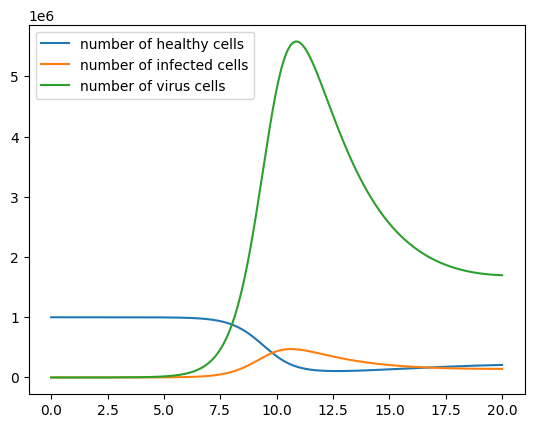

In [12]:
# your code here
import numpy as np
import matplotlib.pyplot as plt

import scipy.integrate as spi
# function that returns dy/dt=[hdot, vdot]
k_1= 100000
k_2 = 0.1
k_3= 0.0000002
k_4 = 0.5
k_5 = 5
k_6= 60


def model(z,t):
  H, I,V = z
  Hdot = k_1 - k_2*H - k_3*H*V                      # dh/dt
  Idot = k_3*H*V - k_4*I
  Vdot = -k_3 * H * V - k_5 * V + k_6*I
  return np.array([Hdot, Idot,Vdot])
ic = [1000000 , 0,100]
# time points
t = np.linspace(0,20,100000)
states = spi.odeint(model,ic,t)
H_numeric = states[:,0]
I_numeric = states[:,1]
V_numeric = states[:,2]
plt.plot(t,H_numeric,label = "number of healthy cells")
plt.plot(t,I_numeric,label = "number of infected cells")
plt.plot(t,V_numeric,label = "number of virus cells")
plt.legend()
plt.show()

_**(Problem 2b)**_ Recall that the patient's condition is extremely bad (_critical_) when the number of infected cells starts to exceed the number of healthy cells. When do you anticipate that to happen? Present the plot that clearly justifies your answer.




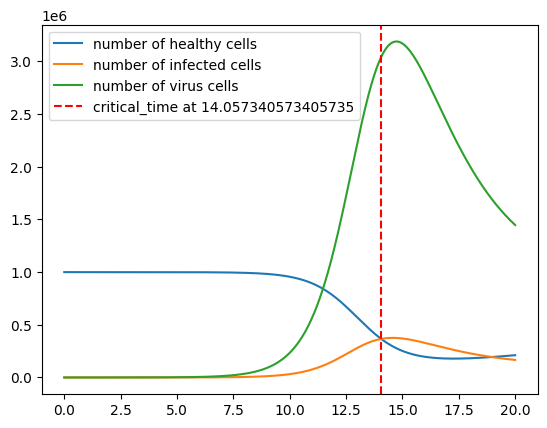

In [29]:
critical_t = 0
# your code here
for i in range(len(t)):
  if H_numeric[i] < I_numeric[i]:
    critical_t = t[i]
    break

plt.plot(t,H_numeric,label = "number of healthy cells")
plt.plot(t,I_numeric,label = "number of infected cells")
plt.plot(t,V_numeric,label = "number of virus cells")
plt.axvline(critical_t,color='r', linestyle='--',label = f"critical_time at {critical_t}")
plt.legend()
plt.show()

_**(Problem 2c)**_ Now you are suggesting a new antiretroviral drug. The drug treatment affects the dynamics for the healthy cells as well as the virus cells, that is,

\begin{align*}
  \dot{H} &= k_1 - k_2 H - k_3 H V - D_H \\
  \dot{I} &= k_3 HV - k_4 I \\
  \dot{V} &= -k_3 HV - k_5 V + k_6 I - D_V
\end{align*}

where $D_H$ and $D_V$ can be interpreted by the number of healthy cells and the number of virus cells that a drug treatment reduces  every year.

From extensive clinical trials and inspections, you are now able to conclude that the following two candidate treatments may be used.

- Treatment A:
$$
\begin{aligned}
  D_H &= 0 \\
  D_V &= 2V
\end{aligned}
$$

- Treatment B:
$$
\begin{aligned}
  D_H &= 10^{-6}H \\
  D_V &= 4\times 10^{-6}V^2  
\end{aligned}
$$

Based on your mathematical models, which of the above would you suggest for the patient? Present the plots that clearly justify your answer.




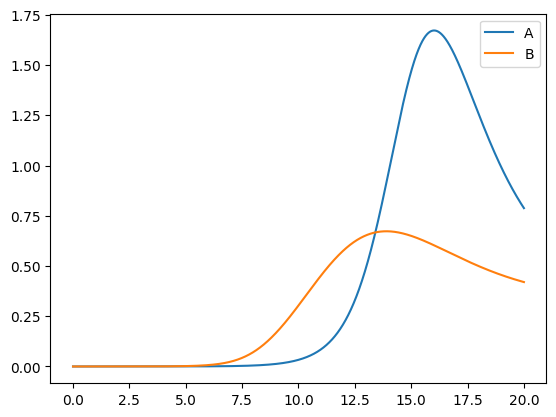

In [28]:
# your code here
# your code here
import numpy as np
import matplotlib.pyplot as plt

import scipy.integrate as spi
# function that returns dy/dt=[hdot, vdot]
k_1= 100000
k_2 = 0.1
k_3= 0.0000002
k_4 = 0.5
k_5 = 5
k_6= 60





def states_A(z,t):

  H, I,V = z
  D_H= 0
  D_V = 2*V
  Hdot = k_1 - k_2*H - k_3*H*V-D_H                      # dh/dt
  Idot = k_3*H*V - k_4*I
  Vdot = -k_3 * H * V - k_5 * V + k_6*I-D_V
  return np.array([Hdot, Idot,Vdot])


def states_B(z,t):

  H, I,V = z
  D_H= 10**(-6) * H
  D_V = 4 * 10**(-6) * V**2
  Hdot = k_1 - k_2*H - k_3*H*V-D_H                      # dh/dt
  Idot = k_3*H*V - k_4*I
  Vdot = -k_3 * H * V - k_5 * V + k_6*I-D_V
  return np.array([Hdot, Idot,Vdot])


ic = [1000000 , 0,100]
# time points
t = np.linspace(0,20,100000)
A = spi.odeint(states_A,ic,t)
H_numeric_A = A[:,0]
I_numeric_A = A[:,1]
V_numeric_A = A[:,2]


B = spi.odeint(states_B,ic,t)
H_numeric_B =B[:,0]
I_numeric_B =B[:,1]
V_numeric_B =B[:,2]


plt.plot(t,I_numeric_A/H_numeric_A,label = "A")
plt.plot(t,I_numeric_B/H_numeric_B,label = "B")
plt.legend()
plt.show()

B를 선택할 것이다.

치명적이지 않게 되기 때문이다.